# 06 Classical Metrics — OpenCV Telea Baseline

This notebook computes full-reference classical image restoration metrics for the OpenCV Telea baseline on the 50-painting controlled subset.

The notebook compares:

1. clean image vs damaged image,
2. clean image vs OpenCV-restored image.

Metrics computed:

- MSE
- MAE
- PSNR
- SSIM

Evaluation regions:

- full image
- painting content region
- masked region
- mask bounding-box crop

SSIM is not computed directly on sparse masked pixels because SSIM requires spatial image structure. For local structural comparison, the mask bounding-box crop is used instead.

In [1]:
from pathlib import Path
import sys
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())
print("Config path:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Experiment config not found: {CONFIG_PATH}")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True
Config path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Config exists: True


In [2]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from restoration_eval.metrics_classical import (
    compute_classical_metrics_for_restorations,
    validate_classical_metrics,
    summarize_classical_metrics,
)

with CONFIG_PATH.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths_cfg = config.get("paths", {})
preprocessing_cfg = config.get("preprocessing", {})

processed_metadata_path = PROJECT_ROOT / paths_cfg["processed_metadata_dir"] / "metadata_processed_clean.csv"
restored_metadata_path = PROJECT_ROOT / paths_cfg["processed_metadata_dir"] / "metadata_restored_opencv_telea.csv"

metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
metrics_dir.mkdir(parents=True, exist_ok=True)

classical_metrics_path = metrics_dir / "classical_metrics_opencv_telea_50.csv"
summary_by_mask_type_path = metrics_dir / "classical_metrics_summary_by_mask_type_opencv_telea_50.csv"
summary_by_category_path = metrics_dir / "classical_metrics_summary_by_category_opencv_telea_50.csv"
summary_by_region_path = metrics_dir / "classical_metrics_summary_by_region_opencv_telea_50.csv"
summary_by_region_mask_type_path = metrics_dir / "classical_metrics_summary_by_region_mask_type_opencv_telea_50.csv"

target_size = (
    preprocessing_cfg.get("output_size")
    or preprocessing_cfg.get("target_size")
    or config.get("experiment", {}).get("image_size")
    or 768
)

mask_bbox_margin = 8

print("Processed metadata path:", processed_metadata_path)
print("Processed metadata exists:", processed_metadata_path.exists())
print("Restored metadata path:", restored_metadata_path)
print("Restored metadata exists:", restored_metadata_path.exists())
print("Metrics directory:", metrics_dir)
print("Classical metrics output:", classical_metrics_path)
print("Target size:", target_size)
print("Mask bbox margin:", mask_bbox_margin)

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed metadata not found: {processed_metadata_path}. "
        "Run Notebook 02 first."
    )

if not restored_metadata_path.exists():
    raise FileNotFoundError(
        f"OpenCV restoration metadata not found: {restored_metadata_path}. "
        "Run Notebook 05 first."
    )

processed_metadata_df = pd.read_csv(processed_metadata_path)
restored_metadata_df = pd.read_csv(restored_metadata_path)

print("\nProcessed metadata shape:", processed_metadata_df.shape)
print("Restored metadata shape:", restored_metadata_df.shape)

display(processed_metadata_df.head())
display(restored_metadata_df.head())

Processed metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Processed metadata exists: True
Restored metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea.csv
Restored metadata exists: True
Metrics directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics
Classical metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_opencv_telea_50.csv
Target size: 768
Mask bbox margin: 8

Processed metadata shape: (50, 43)
Restored metadata shape: (250, 20)


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,padding_color_b,content_x_min,content_y_min,content_x_max,content_y_max,content_width,content_height,preprocessing_method,content_area_pixels,content_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,20,52,0,715,768,663,768,aspect_ratio_resize_median_rgb_pad,509184,86.33
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,35,159,0,608,768,449,768,aspect_ratio_resize_median_rgb_pad,344832,58.46
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,39,77,0,691,768,614,768,aspect_ratio_resize_median_rgb_pad,471552,79.95
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,62,0,71,768,696,768,625,aspect_ratio_resize_median_rgb_pad,480000,81.38
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,34,99,0,668,768,569,768,aspect_ratio_resize_median_rgb_pad,436992,74.09


,case_id,painting_id,mask_id,mask_type,model_name,algorithm,inpaint_radius,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,restored_filename,restored_path,damaged_area_pixels,damaged_area_percentage_content,damaged_area_percentage_full,status,issue
0,p001_loss_large,p001,p001_loss_large,loss_large,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,67242,13.2058,11.4003,ok,NaN
1,p001_loss_small,p001,p001_loss_small,loss_small,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,24198,4.7523,4.1026,ok,NaN
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,44392,8.7183,7.5263,ok,NaN
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,8012,1.5735,1.3584,ok,NaN
4,p001_zero_control,p001,p001_zero_control,zero_control,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,0,0.0000,0.0000,ok,NaN


In [3]:
# Merge OpenCV restoration metadata with processed painting metadata

metadata_columns_to_add = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_width",
    "content_height",
]

missing_processed_columns = [
    col for col in metadata_columns_to_add
    if col not in processed_metadata_df.columns
]

if missing_processed_columns:
    raise ValueError(
        f"Processed metadata is missing required columns for metric evaluation: "
        f"{missing_processed_columns}"
    )

processed_subset_df = processed_metadata_df[metadata_columns_to_add].copy()

metrics_input_df = restored_metadata_df.merge(
    processed_subset_df,
    on="painting_id",
    how="left",
    validate="many_to_one",
)

print("Metrics input shape:", metrics_input_df.shape)

required_metric_input_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_metric_input_columns = [
    col for col in required_metric_input_columns
    if col not in metrics_input_df.columns
]

print("\nRequired-column check:")
if missing_metric_input_columns:
    print("Missing columns:", missing_metric_input_columns)
else:
    print("All required metric input columns are present.")

print("\nRow counts:")
print("Restored metadata rows:", len(restored_metadata_df))
print("Metrics input rows:", len(metrics_input_df))

print("\nMask type counts:")
display(metrics_input_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(metrics_input_df["category"].value_counts().sort_index())

print("\nRestoration status counts:")
display(metrics_input_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(metrics_input_df["issue"].fillna("").replace("", "ok").value_counts())

if missing_metric_input_columns:
    raise ValueError("Metrics input metadata is missing required columns.")

if len(metrics_input_df) != 250:
    raise ValueError(f"Expected 250 OpenCV restoration rows, found {len(metrics_input_df)}.")

if metrics_input_df["case_id"].duplicated().any():
    duplicate_cases = metrics_input_df.loc[
        metrics_input_df["case_id"].duplicated(),
        "case_id",
    ].tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_cases[:10]}")

if metrics_input_df["category"].isna().any():
    missing_category_rows = metrics_input_df[metrics_input_df["category"].isna()]
    display(missing_category_rows[["case_id", "painting_id", "mask_type"]])
    raise ValueError("Some metric rows are missing category values.")

if (metrics_input_df["status"] != "ok").any():
    failed_rows = metrics_input_df[metrics_input_df["status"] != "ok"]
    display(failed_rows)
    raise ValueError("Some OpenCV restoration rows have non-ok status.")

print("\nClassical metric input gate passed.")
display(metrics_input_df.head())

Metrics input shape: (250, 28)

Required-column check:
All required metric input columns are present.

Row counts:
Restored metadata rows: 250
Metrics input rows: 250

Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64


Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64


Restoration status counts:


status
ok    250
Name: count, dtype: int64


Issue counts:


issue
ok    250
Name: count, dtype: int64


Classical metric input gate passed.


,case_id,painting_id,mask_id,mask_type,model_name,algorithm,inpaint_radius,clean_filename,clean_path,mask_filename,...,status,issue,category,title,content_x_min,content_y_min,content_x_max,content_y_max,content_width,content_height
0,p001_loss_large,p001,p001_loss_large,loss_large,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
1,p001_loss_small,p001,p001_loss_small,loss_small,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
4,p001_zero_control,p001,p001_zero_control,zero_control,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768


In [4]:
# One-painting classical metrics test

test_painting_id = (
    metrics_input_df
    .sort_values("painting_id")
    .iloc[0]["painting_id"]
)

test_metrics_input_df = (
    metrics_input_df[metrics_input_df["painting_id"] == test_painting_id]
    .copy()
)

print("Test painting ID:", test_painting_id)
print("Input rows:", len(test_metrics_input_df))

display(
    test_metrics_input_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "model_name",
            "damaged_area_percentage_content",
        ]
    ].sort_values("mask_type")
)

test_classical_metrics_df = compute_classical_metrics_for_restorations(
    restoration_metadata=test_metrics_input_df,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
)

print("Generated test metric rows:", len(test_classical_metrics_df))
print("Expected test metric rows: 18")

print("\nRows by evaluation region:")
display(test_classical_metrics_df["evaluation_region"].value_counts().sort_index())

print("\nRows by mask type:")
display(test_classical_metrics_df["mask_type"].value_counts().sort_index())

print("\nStatus counts:")
display(test_classical_metrics_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(test_classical_metrics_df["issue"].fillna("").replace("", "ok").value_counts())

display(test_classical_metrics_df.head(20))

Test painting ID: p001
Input rows: 5


,case_id,painting_id,category,mask_type,model_name,damaged_area_percentage_content
0,p001_loss_large,p001,portrait_figure,loss_large,opencv_telea,13.2058
1,p001_loss_small,p001,portrait_figure,loss_small,opencv_telea,4.7523
2,p001_mixed_damage,p001,portrait_figure,mixed_damage,opencv_telea,8.7183
3,p001_scratch_thin,p001,portrait_figure,scratch_thin,opencv_telea,1.5735
4,p001_zero_control,p001,portrait_figure,zero_control,opencv_telea,0.0000


Generated test metric rows: 18
Expected test metric rows: 18

Rows by evaluation region:


evaluation_region
content_region    5
full_image        5
mask_bbox_crop    4
masked_region     4
Name: count, dtype: int64


Rows by mask type:


...


Status counts:


status
ok    18
Name: count, dtype: int64


Issue counts:


issue
ok    18
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0.0,...,2.166397,22.892098,10.659855,27.641154,16.981299,0.897178,0.961985,0.064807,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52.0,...,2.509491,26.517544,10.021378,27.002677,16.981299,0.880745,0.955910,0.075165,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,masked_region,67242,NaN,...,19.002895,200.801716,1.229037,18.210336,16.981299,NaN,NaN,NaN,ok,
3,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,126750,221.0,...,10.081204,106.527087,3.982110,20.963409,16.981299,0.512661,0.819825,0.307164,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0.0,...,0.145845,8.718577,15.279670,46.856186,31.576516,0.953800,0.994575,0.040775,ok,
5,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,content_region,509184,52.0,...,0.168942,10.099347,14.641193,46.217710,31.576516,0.946416,0.993708,0.047291,ok,
6,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,masked_region,24198,NaN,...,3.554950,212.514508,1.410241,32.986756,31.576516,NaN,NaN,NaN,ok,
7,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,mask_bbox_crop,306081,72.0,...,0.281045,16.800866,12.430810,44.007326,31.576516,0.910404,0.989479,0.079075,ok,
8,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,p001_mixed_damage,mixed_damage,opencv_telea,full_image,589824,0.0,...,0.590430,16.303689,12.311416,35.945336,23.633920,0.906229,0.981393,0.075163,ok,
9,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,p001_mixed_damage,mixed_damage,opencv_telea,content_region,509184,52.0,...,0.683937,18.885722,11.672939,35.306859,23.633920,0.893274,0.979542,0.086268,ok,


In [5]:
# Inspect test metric sanity

print("Zero-control rows:")
zero_test_df = test_classical_metrics_df[
    test_classical_metrics_df["mask_type"] == "zero_control"
].copy()

display(
    zero_test_df[
        [
            "case_id",
            "evaluation_region",
            "damaged_mse",
            "restored_mse",
            "damaged_mae",
            "restored_mae",
            "damaged_psnr",
            "restored_psnr",
            "damaged_ssim",
            "restored_ssim",
            "mse_improvement",
            "mae_improvement",
            "psnr_improvement",
            "ssim_improvement",
        ]
    ]
)

print("\nOne non-zero example:")
nonzero_test_df = test_classical_metrics_df[
    test_classical_metrics_df["mask_type"] != "zero_control"
].copy()

example_case_id = (
    nonzero_test_df
    .sort_values(["mask_type", "evaluation_region"])
    .iloc[0]["case_id"]
)

example_df = nonzero_test_df[
    nonzero_test_df["case_id"] == example_case_id
].copy()

print("Example case:", example_case_id)

display(
    example_df[
        [
            "case_id",
            "mask_type",
            "evaluation_region",
            "region_pixel_count",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_mae",
            "restored_mae",
            "mae_improvement",
            "damaged_psnr",
            "restored_psnr",
            "psnr_improvement",
            "damaged_ssim",
            "restored_ssim",
            "ssim_improvement",
        ]
    ]
)

print("\nMasked-region SSIM check:")
display(
    test_classical_metrics_df[
        test_classical_metrics_df["evaluation_region"] == "masked_region"
    ][
        [
            "case_id",
            "mask_type",
            "evaluation_region",
            "damaged_ssim",
            "restored_ssim",
            "ssim_improvement",
        ]
    ]
)

Zero-control rows:


,case_id,evaluation_region,damaged_mse,restored_mse,damaged_mae,restored_mae,damaged_psnr,restored_psnr,damaged_ssim,restored_ssim,mse_improvement,mae_improvement,psnr_improvement,ssim_improvement
16,p001_zero_control,full_image,0.0,0.0,0.0,0.0,inf,inf,1.0,1.0,0.0,0.0,NaN,0.0
17,p001_zero_control,content_region,0.0,0.0,0.0,0.0,inf,inf,1.0,1.0,0.0,0.0,NaN,0.0



One non-zero example:
Example case: p001_loss_large


,case_id,mask_type,evaluation_region,region_pixel_count,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement
0,p001_loss_large,loss_large,full_image,589824,5585.921875,111.934753,5473.987122,25.058495,2.166397,22.892098,10.659855,27.641154,16.981299,0.897178,0.961985,0.064807
1,p001_loss_large,loss_large,content_region,509184,6470.570312,129.661972,6340.908340,29.027035,2.509491,26.517544,10.021378,27.002677,16.981299,0.880745,0.955910,0.075165
2,p001_loss_large,loss_large,masked_region,67242,48997.804688,981.853638,48015.951050,219.804611,19.002895,200.801716,1.229037,18.210336,16.981299,NaN,NaN,NaN
3,p001_loss_large,loss_large,mask_bbox_crop,126750,25993.773438,520.882080,25472.891357,116.608292,10.081204,106.527087,3.982110,20.963409,16.981299,0.512661,0.819825,0.307164



Masked-region SSIM check:


,case_id,mask_type,evaluation_region,damaged_ssim,restored_ssim,ssim_improvement
2,p001_loss_large,loss_large,masked_region,NaN,NaN,NaN
6,p001_loss_small,loss_small,masked_region,NaN,NaN,NaN
10,p001_mixed_damage,mixed_damage,masked_region,NaN,NaN,NaN
14,p001_scratch_thin,scratch_thin,masked_region,NaN,NaN,NaN


In [6]:
# Compute classical metrics for all OpenCV restoration cases

classical_metrics_df = compute_classical_metrics_for_restorations(
    restoration_metadata=metrics_input_df,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
)

print("Classical metric computation complete.")
print("Rows:", len(classical_metrics_df))
print("Expected rows: 900")

print("\nRows by evaluation region:")
display(classical_metrics_df["evaluation_region"].value_counts().sort_index())

print("\nRows by mask type:")
display(classical_metrics_df["mask_type"].value_counts().sort_index())

print("\nStatus counts:")
display(classical_metrics_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(classical_metrics_df["issue"].fillna("").replace("", "ok").value_counts())

display(classical_metrics_df.head())

Classical metric computation complete.
Rows: 900
Expected rows: 900

Rows by evaluation region:


evaluation_region
content_region    250
full_image        250
mask_bbox_crop    200
masked_region     200
Name: count, dtype: int64


Rows by mask type:


mask_type
loss_large      200
loss_small      200
mixed_damage    200
scratch_thin    200
zero_control    100
Name: count, dtype: int64


Status counts:


status
ok    900
Name: count, dtype: int64


Issue counts:


issue
ok    900
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0.0,...,2.166397,22.892098,10.659855,27.641154,16.981299,0.897178,0.961985,0.064807,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52.0,...,2.509491,26.517544,10.021378,27.002677,16.981299,0.880745,0.955910,0.075165,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,masked_region,67242,NaN,...,19.002895,200.801716,1.229037,18.210336,16.981299,NaN,NaN,NaN,ok,
3,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,126750,221.0,...,10.081204,106.527087,3.982110,20.963409,16.981299,0.512661,0.819825,0.307164,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0.0,...,0.145845,8.718577,15.279670,46.856186,31.576516,0.953800,0.994575,0.040775,ok,


In [7]:
# Save full classical metrics

classical_metrics_df.to_csv(classical_metrics_path, index=False)

print("Classical metrics saved:")
print(classical_metrics_path)
print("Saved file exists:", classical_metrics_path.exists())
print("Rows saved:", len(classical_metrics_df))
print("Columns:", len(classical_metrics_df.columns))

reloaded_classical_metrics_df = pd.read_csv(classical_metrics_path)

print("\nReloaded shape:", reloaded_classical_metrics_df.shape)
display(reloaded_classical_metrics_df.head())

Classical metrics saved:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_opencv_telea_50.csv
Saved file exists: True
Rows saved: 900
Columns: 30

Reloaded shape: (900, 30)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0.0,...,2.166397,22.892098,10.659855,27.641154,16.981299,0.897178,0.961985,0.064807,ok,NaN
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52.0,...,2.509491,26.517544,10.021378,27.002677,16.981299,0.880745,0.955910,0.075165,ok,NaN
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,masked_region,67242,NaN,...,19.002895,200.801716,1.229037,18.210336,16.981299,NaN,NaN,NaN,ok,NaN
3,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,126750,221.0,...,10.081204,106.527087,3.982110,20.963409,16.981299,0.512661,0.819825,0.307164,ok,NaN
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0.0,...,0.145845,8.718577,15.279670,46.856186,31.576516,0.953800,0.994575,0.040775,ok,NaN


In [8]:
# Validate full classical metrics output

classical_metrics_validation_df = validate_classical_metrics(
    metrics_df=classical_metrics_df,
    expected_rows=900,
)

display(classical_metrics_validation_df)

if not classical_metrics_validation_df["passed"].all():
    raise ValueError("Classical metrics validation failed.")

print("Classical metrics validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 900, found 900."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


Classical metrics validation passed.


In [9]:
# Metric value sanity checks

ok_metrics_df = classical_metrics_df[classical_metrics_df["status"] == "ok"].copy()

zero_control_df = ok_metrics_df[ok_metrics_df["mask_type"] == "zero_control"].copy()
nonzero_df = ok_metrics_df[ok_metrics_df["mask_type"] != "zero_control"].copy()
masked_region_df = ok_metrics_df[ok_metrics_df["evaluation_region"] == "masked_region"].copy()

print("Zero-control rows:", len(zero_control_df))
print("Non-zero mask rows:", len(nonzero_df))
print("Masked-region rows:", len(masked_region_df))

# Zero-control should only have full_image and content_region rows.
print("\nZero-control evaluation regions:")
display(zero_control_df["evaluation_region"].value_counts().sort_index())

# Zero-control should have no error.
zero_mse_max = zero_control_df[["damaged_mse", "restored_mse"]].replace([np.inf, -np.inf], np.nan).max().max()
zero_mae_max = zero_control_df[["damaged_mae", "restored_mae"]].replace([np.inf, -np.inf], np.nan).max().max()
zero_ssim_min = zero_control_df[["damaged_ssim", "restored_ssim"]].min().min()

print("\nZero-control max MSE:", zero_mse_max)
print("Zero-control max MAE:", zero_mae_max)
print("Zero-control min SSIM:", zero_ssim_min)

if zero_mse_max != 0:
    raise ValueError("Zero-control MSE is not zero.")

if zero_mae_max != 0:
    raise ValueError("Zero-control MAE is not zero.")

if zero_ssim_min != 1:
    raise ValueError("Zero-control SSIM is not one.")

# Masked-region SSIM should be NaN by design.
masked_region_ssim_non_null = masked_region_df[
    ["damaged_ssim", "restored_ssim", "ssim_improvement"]
].notna().sum().sum()

print("\nMasked-region non-null SSIM values:", masked_region_ssim_non_null)

if masked_region_ssim_non_null != 0:
    raise ValueError("Masked-region SSIM should be NaN by design.")

# Most non-zero cases should improve in masked-region MSE.
masked_region_improvement_rate = (
    masked_region_df["mse_improvement"] > 0
).mean()

print("\nMasked-region MSE improvement rate:", round(masked_region_improvement_rate, 4))

display(
    masked_region_df
    .groupby("mask_type")
    .agg(
        cases=("case_id", "count"),
        mean_damaged_mse=("damaged_mse", "mean"),
        mean_restored_mse=("restored_mse", "mean"),
        mean_mse_improvement=("mse_improvement", "mean"),
        improvement_rate=("mse_improvement", lambda x: (x > 0).mean()),
    )
    .round(4)
    .reset_index()
)

print("\nMetric sanity checks passed.")

Zero-control rows: 100
Non-zero mask rows: 800
Masked-region rows: 200

Zero-control evaluation regions:


evaluation_region
content_region    50
full_image        50
Name: count, dtype: int64


Zero-control max MSE: 0.0
Zero-control max MAE: 0.0
Zero-control min SSIM: 1.0

Masked-region non-null SSIM values: 0

Masked-region MSE improvement rate: 1.0


,mask_type,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,improvement_rate
0,loss_large,50,25580.7231,1580.9898,23999.7333,1.0
1,loss_small,50,26519.8802,616.9986,25902.8816,1.0
2,mixed_damage,50,27237.5942,855.7749,26381.8193,1.0
3,scratch_thin,50,28644.7329,325.0640,28319.6689,1.0



Metric sanity checks passed.


In [10]:
# Create classical metric summary tables

# Summary by evaluation region
summary_by_region_df = summarize_classical_metrics(
    metrics_df=classical_metrics_df,
    group_columns=["evaluation_region"],
)

# Summary by mask type
summary_by_mask_type_df = summarize_classical_metrics(
    metrics_df=classical_metrics_df,
    group_columns=["mask_type"],
)

# Summary by category
summary_by_category_df = summarize_classical_metrics(
    metrics_df=classical_metrics_df,
    group_columns=["category"],
)

# Summary by evaluation region and mask type
summary_by_region_mask_type_df = summarize_classical_metrics(
    metrics_df=classical_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

print("Summary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

Summary by evaluation region:


,evaluation_region,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,content_region,250,250,1572.5250,65.5288,1506.9961,8.9654,1.1569,7.8086,16.6442,33.1181,16.4739,0.9367,0.9732,0.0366,454656.000
1,full_image,250,250,1203.4601,52.6391,1150.8210,6.8571,0.9017,5.9554,17.8125,34.2864,16.4739,0.9506,0.9791,0.0285,589824.000
2,mask_bbox_crop,200,200,4835.2007,238.1367,4597.0640,27.8695,4.1486,23.7209,14.4229,30.8969,16.4739,0.8288,0.9074,0.0785,318789.815
3,masked_region,200,200,26995.7326,844.7068,26151.0258,152.7505,16.3037,136.4468,4.3305,20.8044,16.4739,NaN,NaN,NaN,33543.270



Summary by mask type:


,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,loss_large,200,50,11323.9830,692.3707,10631.6123,65.5425,11.2286,54.3140,10.0675,22.6830,12.6155,0.8031,0.8669,0.0638,304707.235
1,loss_small,200,50,7656.2517,177.8278,7478.4238,43.9286,4.0025,39.9260,14.2766,31.6697,17.3931,0.9478,0.9776,0.0298,334144.560
2,mixed_damage,200,50,8715.1308,274.1615,8440.9693,49.2290,5.4084,43.8206,12.0471,27.4431,15.3960,0.8917,0.9582,0.0665,384264.205
3,scratch_thin,200,50,7605.5491,86.1934,7519.3557,41.6982,2.3859,39.3122,16.8189,37.3100,20.4911,0.9411,0.9943,0.0531,373697.085
4,zero_control,100,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,522240.000



Summary by category:


,category,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,abstraction_surrealism,180,50,5931.7555,492.9764,5438.7791,36.4359,6.5455,29.8904,14.7821,27.4454,12.6633,0.9203,0.9573,0.0370,392566.9000
1,architecture_structured,180,50,7612.3011,234.9856,7377.3155,44.7338,5.0029,39.7309,13.1676,30.1883,17.0206,0.9090,0.9542,0.0452,357633.6389
2,high_texture_brushwork,180,50,7923.2861,208.1827,7715.1033,46.0922,4.7323,41.3600,12.8508,30.2928,17.4420,0.9098,0.9551,0.0453,371109.8500
3,landscape_natural,180,50,6464.3338,240.1860,6224.1478,39.8556,5.1088,34.7468,14.3116,29.5550,15.2434,0.9124,0.9534,0.0410,350709.4500
4,portrait_figure,180,50,11291.5619,190.9507,11100.6111,55.5473,4.1945,51.3528,11.4005,31.4007,20.0002,0.9026,0.9625,0.0599,370128.0333



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,content_region,loss_large,50,50,3298.9743,208.1588,3090.8154,19.0271,3.2784,15.7487,13.5845,26.2000,12.6155,0.9031,0.9346,0.0315,454656.00
1,content_region,loss_small,50,50,1185.8752,26.3560,1159.5192,6.7963,0.6053,6.1910,17.9830,35.3761,17.3931,0.9555,0.9811,0.0257,454656.00
2,content_region,mixed_damage,50,50,2744.7068,86.0537,2658.6531,15.5419,1.7071,13.8347,14.2714,29.6674,15.3960,0.8852,0.9558,0.0705,454656.00
3,content_region,scratch_thin,50,50,633.0685,7.0755,625.9930,3.4620,0.1935,3.2685,20.7378,41.2289,20.4911,0.9395,0.9946,0.0552,454656.00
4,content_region,zero_control,50,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,454656.00
5,full_image,loss_large,50,50,2550.7766,170.3802,2380.3965,14.7026,2.5922,12.1103,14.7528,27.3683,12.6155,0.9253,0.9493,0.0240,589824.00
6,full_image,loss_small,50,50,901.8392,21.2281,880.6111,5.1609,0.4691,4.6918,19.1513,36.5444,17.3931,0.9662,0.9856,0.0194,589824.00
7,full_image,mixed_damage,50,50,2083.1693,66.2633,2016.9060,11.7803,1.2999,10.4803,15.4397,30.8357,15.3960,0.9105,0.9656,0.0552,589824.00
8,full_image,scratch_thin,50,50,481.5154,5.3239,476.1915,2.6420,0.1473,2.4947,21.9061,42.3972,20.4911,0.9510,0.9950,0.0441,589824.00
9,full_image,zero_control,50,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,589824.00


In [11]:
# Save classical metric summary tables

summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)

print("Saved summary by region:", summary_by_region_path)
print("Exists:", summary_by_region_path.exists())

print("\nSaved summary by mask type:", summary_by_mask_type_path)
print("Exists:", summary_by_mask_type_path.exists())

print("\nSaved summary by category:", summary_by_category_path)
print("Exists:", summary_by_category_path.exists())

print("\nSaved summary by region and mask type:", summary_by_region_mask_type_path)
print("Exists:", summary_by_region_mask_type_path.exists())

Saved summary by region: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_region_opencv_telea_50.csv
Exists: True

Saved summary by mask type: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_mask_type_opencv_telea_50.csv
Exists: True

Saved summary by category: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_category_opencv_telea_50.csv
Exists: True

Saved summary by region and mask type: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_region_mask_type_opencv_telea_50.csv
Exists: True


In [12]:
# Focused masked-region summary for OpenCV restoration

masked_region_summary_df = (
    classical_metrics_df[
        (classical_metrics_df["evaluation_region"] == "masked_region")
        & (classical_metrics_df["mask_type"] != "zero_control")
        & (classical_metrics_df["status"] == "ok")
    ]
    .groupby("mask_type")
    .agg(
        cases=("case_id", "count"),
        mean_damaged_mse=("damaged_mse", "mean"),
        mean_restored_mse=("restored_mse", "mean"),
        mean_mse_improvement=("mse_improvement", "mean"),
        mean_damaged_mae=("damaged_mae", "mean"),
        mean_restored_mae=("restored_mae", "mean"),
        mean_mae_improvement=("mae_improvement", "mean"),
        mean_damaged_psnr=("damaged_psnr", "mean"),
        mean_restored_psnr=("restored_psnr", "mean"),
        mean_psnr_improvement=("psnr_improvement", "mean"),
        improvement_rate_mse=("mse_improvement", lambda x: (x > 0).mean()),
        improvement_rate_mae=("mae_improvement", lambda x: (x > 0).mean()),
        mean_region_pixel_count=("region_pixel_count", "mean"),
    )
    .round(4)
    .reset_index()
)

masked_region_summary_path = metrics_dir / "classical_metrics_masked_region_summary_opencv_telea_50.csv"
masked_region_summary_df.to_csv(masked_region_summary_path, index=False)

print("Masked-region summary:")
display(masked_region_summary_df)

print("\nSaved masked-region summary:", masked_region_summary_path)
print("Exists:", masked_region_summary_path.exists())

Masked-region summary:


,mask_type,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,improvement_rate_mse,improvement_rate_mae,mean_region_pixel_count
0,loss_large,50,25580.7231,1580.9898,23999.7333,148.1165,25.4762,122.6403,4.5927,17.2082,12.6155,1.0,1.0,58769.48
1,loss_small,50,26519.8802,616.9986,25902.8816,152.0709,13.8619,138.2090,4.3729,21.7660,17.3931,1.0,1.0,19951.84
2,mixed_damage,50,27237.5942,855.7749,26381.8193,153.7445,16.8750,136.8694,4.2923,19.6883,15.3960,1.0,1.0,45450.92
3,scratch_thin,50,28644.7329,325.0640,28319.6689,157.0701,9.0014,148.0687,4.0641,24.5552,20.4911,1.0,1.0,10000.84



Saved masked-region summary: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_masked_region_summary_opencv_telea_50.csv
Exists: True


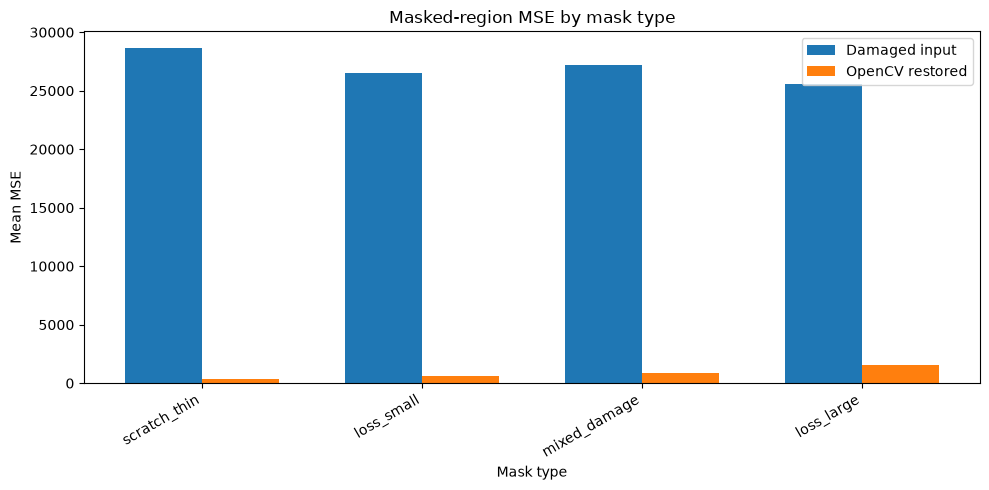

In [13]:
# Diagnostic plot: masked-region MSE before and after OpenCV restoration

plot_df = masked_region_summary_df.sort_values("mean_restored_mse").copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    plot_df["mean_damaged_mse"],
    width,
    label="Damaged input",
)

ax.bar(
    x + width / 2,
    plot_df["mean_restored_mse"],
    width,
    label="OpenCV restored",
)

ax.set_title("Masked-region MSE by mask type")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean MSE")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["mask_type"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

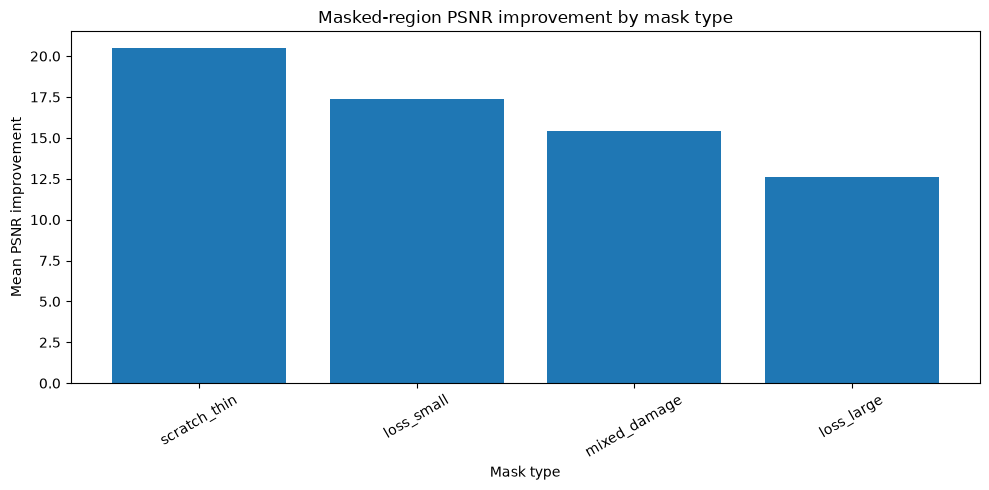

In [14]:
# Diagnostic plot: masked-region PSNR improvement after OpenCV restoration

plot_df = masked_region_summary_df.sort_values("mean_psnr_improvement", ascending=False).copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    plot_df["mask_type"],
    plot_df["mean_psnr_improvement"],
)

ax.set_title("Masked-region PSNR improvement by mask type")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean PSNR improvement")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [15]:
# Inspect strongest and weakest OpenCV cases by masked-region MSE improvement

masked_region_cases_df = classical_metrics_df[
    (classical_metrics_df["evaluation_region"] == "masked_region")
    & (classical_metrics_df["mask_type"] != "zero_control")
    & (classical_metrics_df["status"] == "ok")
].copy()

strongest_cases_df = (
    masked_region_cases_df
    .sort_values("mse_improvement", ascending=False)
    .head(10)
)

weakest_cases_df = (
    masked_region_cases_df
    .sort_values("mse_improvement", ascending=True)
    .head(10)
)

print("Strongest OpenCV improvements by masked-region MSE:")
display(
    strongest_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_mae",
            "restored_mae",
            "psnr_improvement",
        ]
    ]
)

print("\nWeakest OpenCV improvements by masked-region MSE:")
display(
    weakest_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_mae",
            "restored_mae",
            "psnr_improvement",
        ]
    ]
)

Strongest OpenCV improvements by masked-region MSE:


,case_id,painting_id,category,title,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,psnr_improvement
100,p006_mixed_damage,p006,portrait_figure,Boy with a Sword,mixed_damage,51966.464844,125.127579,51841.337265,227.115143,5.385486,26.183701
92,p006_loss_large,p006,portrait_figure,Boy with a Sword,loss_large,52182.816406,344.240997,51838.575409,227.927567,11.803576,21.806649
104,p006_scratch_thin,p006,portrait_figure,Boy with a Sword,scratch_thin,51070.074219,72.985008,50997.089211,224.160110,3.604586,28.449328
20,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,51229.847656,315.289917,50914.557739,225.618668,11.879395,22.108130
10,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,50740.699219,219.768036,50520.931183,224.467407,7.844874,23.633919
32,p002_scratch_thin,p002,portrait_figure,Madame X (Madame Pierre Gautreau),scratch_thin,50183.656250,69.275764,50114.380486,222.061203,3.182986,28.599810
96,p006_loss_small,p006,portrait_figure,Boy with a Sword,loss_small,49847.980469,67.878677,49780.101791,222.692871,3.346245,28.659142
14,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,48508.558594,173.122025,48335.436569,217.938049,6.558288,24.474660
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,48997.804688,981.853638,48015.951050,219.804611,19.002895,16.981299
6,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,46995.500000,32.689232,46962.810768,216.069458,3.554950,31.576516



Weakest OpenCV improvements by masked-region MSE:


,case_id,painting_id,category,title,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,psnr_improvement
632,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_large,5263.032715,4746.762695,516.270020,46.358219,30.242277,0.448385
644,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,2009.945190,38.385235,1971.559956,29.343353,1.609061,17.190200
568,p032_mixed_damage,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,mixed_damage,2763.684082,478.977264,2284.706818,40.720081,7.431790,7.611735
636,p036_loss_small,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_small,3290.943115,847.450195,2443.492920,37.022774,7.999779,5.892062
560,p032_loss_large,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_large,7354.854004,4368.197754,2986.656250,61.183590,32.821705,2.262718
640,p036_mixed_damage,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",mixed_damage,4701.547852,1155.855225,3545.692627,42.428127,10.897691,6.093374
348,p020_loss_small,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_small,4237.945801,256.513458,3981.432343,62.286888,9.104131,12.180452
352,p020_mixed_damage,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,mixed_damage,4976.782227,436.240509,4540.541718,62.755474,11.996895,10.572226
740,p042_loss_large,p042,high_texture_brushwork,View of Beirut,loss_large,5220.112793,35.873093,5184.239700,70.196960,4.576962,21.629111
344,p020_loss_large,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_large,6440.326660,1214.796509,5225.530151,72.366478,25.514084,7.244044


In [16]:
# Save strongest and weakest OpenCV case tables

strongest_cases_path = metrics_dir / "opencv_strongest_masked_region_cases_50.csv"
weakest_cases_path = metrics_dir / "opencv_weakest_masked_region_cases_50.csv"

strongest_cases_df.to_csv(strongest_cases_path, index=False)
weakest_cases_df.to_csv(weakest_cases_path, index=False)

print("Saved strongest cases:", strongest_cases_path)
print("Exists:", strongest_cases_path.exists())

print("\nSaved weakest cases:", weakest_cases_path)
print("Exists:", weakest_cases_path.exists())

Saved strongest cases: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\opencv_strongest_masked_region_cases_50.csv
Exists: True

Saved weakest cases: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\opencv_weakest_masked_region_cases_50.csv
Exists: True


In [17]:
# Visual comparison helper for selected metric cases

def show_case_comparisons(case_rows_df, title, max_cases=3):
    """Display clean, mask, damaged, and restored images for selected cases."""
    selected_rows = case_rows_df.head(max_cases).copy()

    fig, axes = plt.subplots(len(selected_rows), 4, figsize=(16, 4 * len(selected_rows)))

    if len(selected_rows) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (_, metric_row) in enumerate(selected_rows.iterrows()):
        case_id = metric_row["case_id"]

        metadata_row = metrics_input_df[metrics_input_df["case_id"] == case_id].iloc[0]

        clean_path = Path(metadata_row["clean_path"])
        mask_path = Path(metadata_row["mask_path"])
        damaged_path = Path(metadata_row["damaged_path"])
        restored_path = Path(metadata_row["restored_path"])

        with Image.open(clean_path) as img:
            clean_img = img.convert("RGB")

        with Image.open(mask_path) as img:
            mask_img = img.convert("L")

        with Image.open(damaged_path) as img:
            damaged_img = img.convert("RGB")

        with Image.open(restored_path) as img:
            restored_img = img.convert("RGB")

        subtitle = (
            f"{metric_row['case_id']} | {metric_row['category']} | {metric_row['mask_type']}\n"
            f"MSE improvement: {metric_row['mse_improvement']:.2f}"
        )

        axes[row_idx, 0].imshow(clean_img)
        axes[row_idx, 0].set_title("Clean", fontsize=10)
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(mask_img, cmap="gray", vmin=0, vmax=255)
        axes[row_idx, 1].set_title("Mask", fontsize=10)
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(damaged_img)
        axes[row_idx, 2].set_title("Damaged", fontsize=10)
        axes[row_idx, 2].axis("off")

        axes[row_idx, 3].imshow(restored_img)
        axes[row_idx, 3].set_title("OpenCV restored", fontsize=10)
        axes[row_idx, 3].axis("off")

        axes[row_idx, 0].text(
            0,
            -0.08,
            subtitle,
            transform=axes[row_idx, 0].transAxes,
            fontsize=9,
            va="top",
        )

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

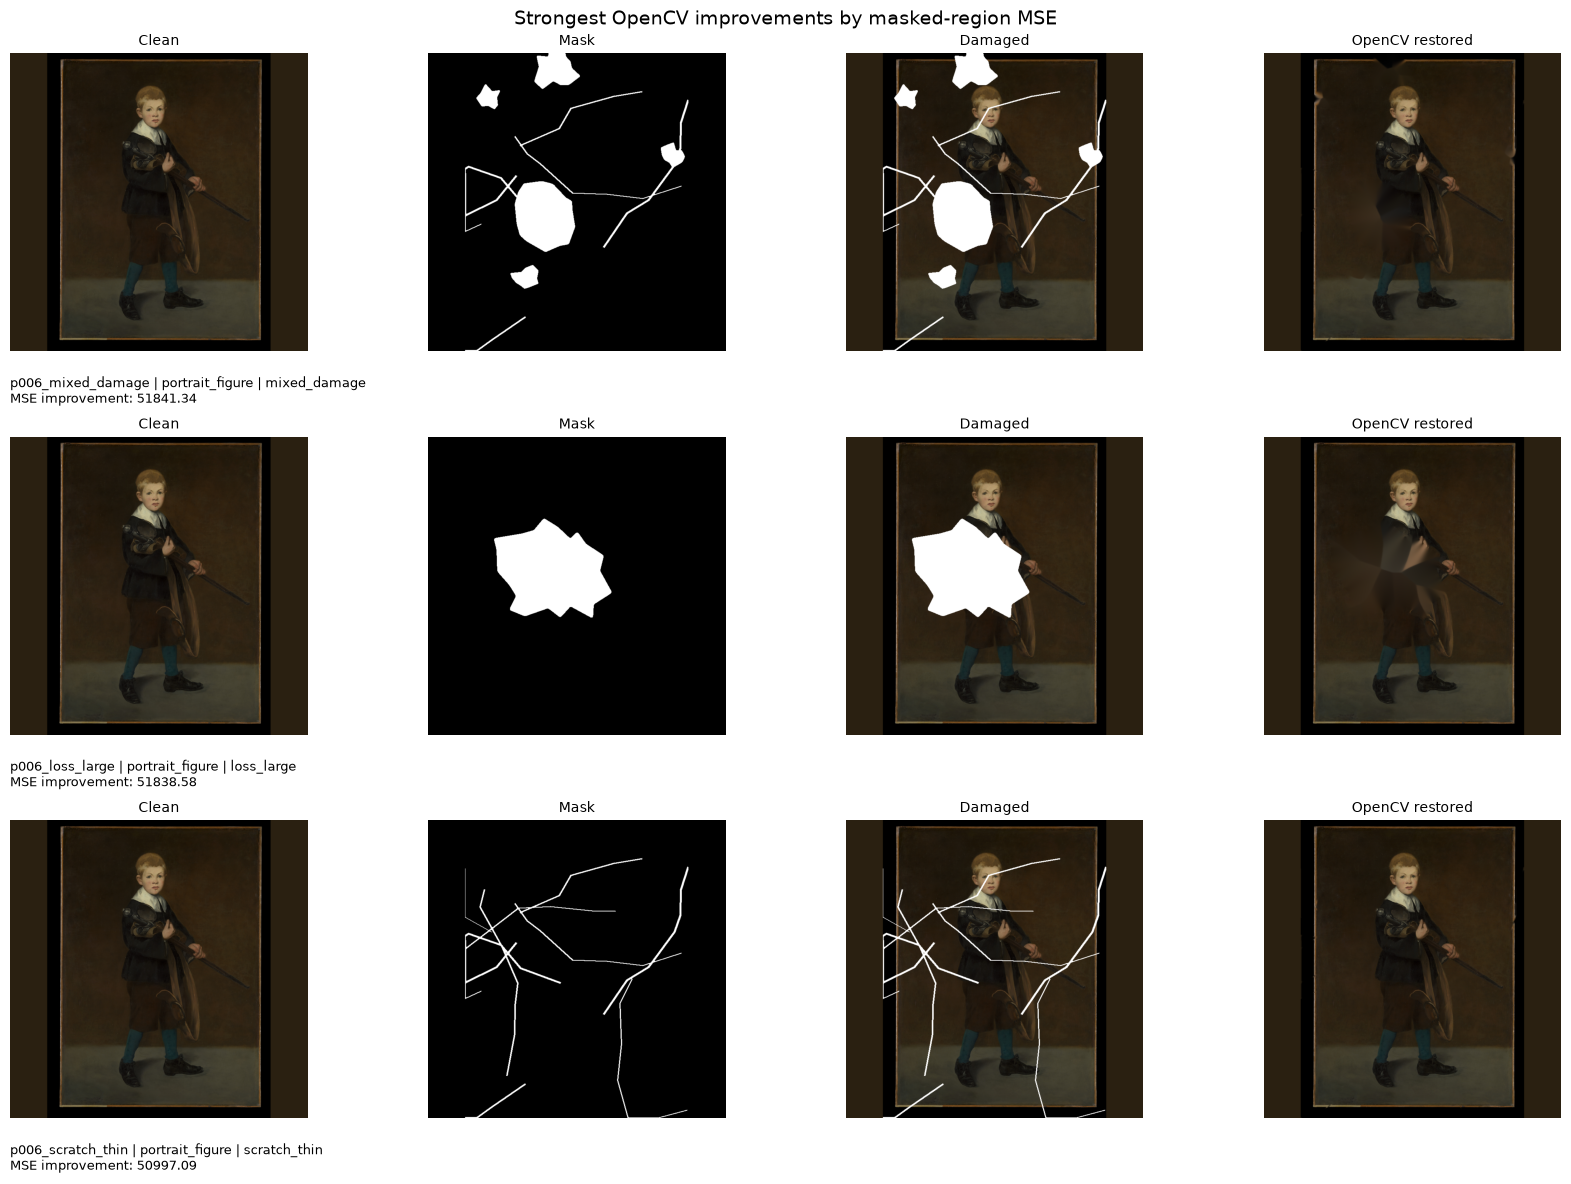

In [18]:
# Visualize strongest OpenCV cases by masked-region MSE improvement

show_case_comparisons(
    strongest_cases_df,
    title="Strongest OpenCV improvements by masked-region MSE",
    max_cases=3,
)

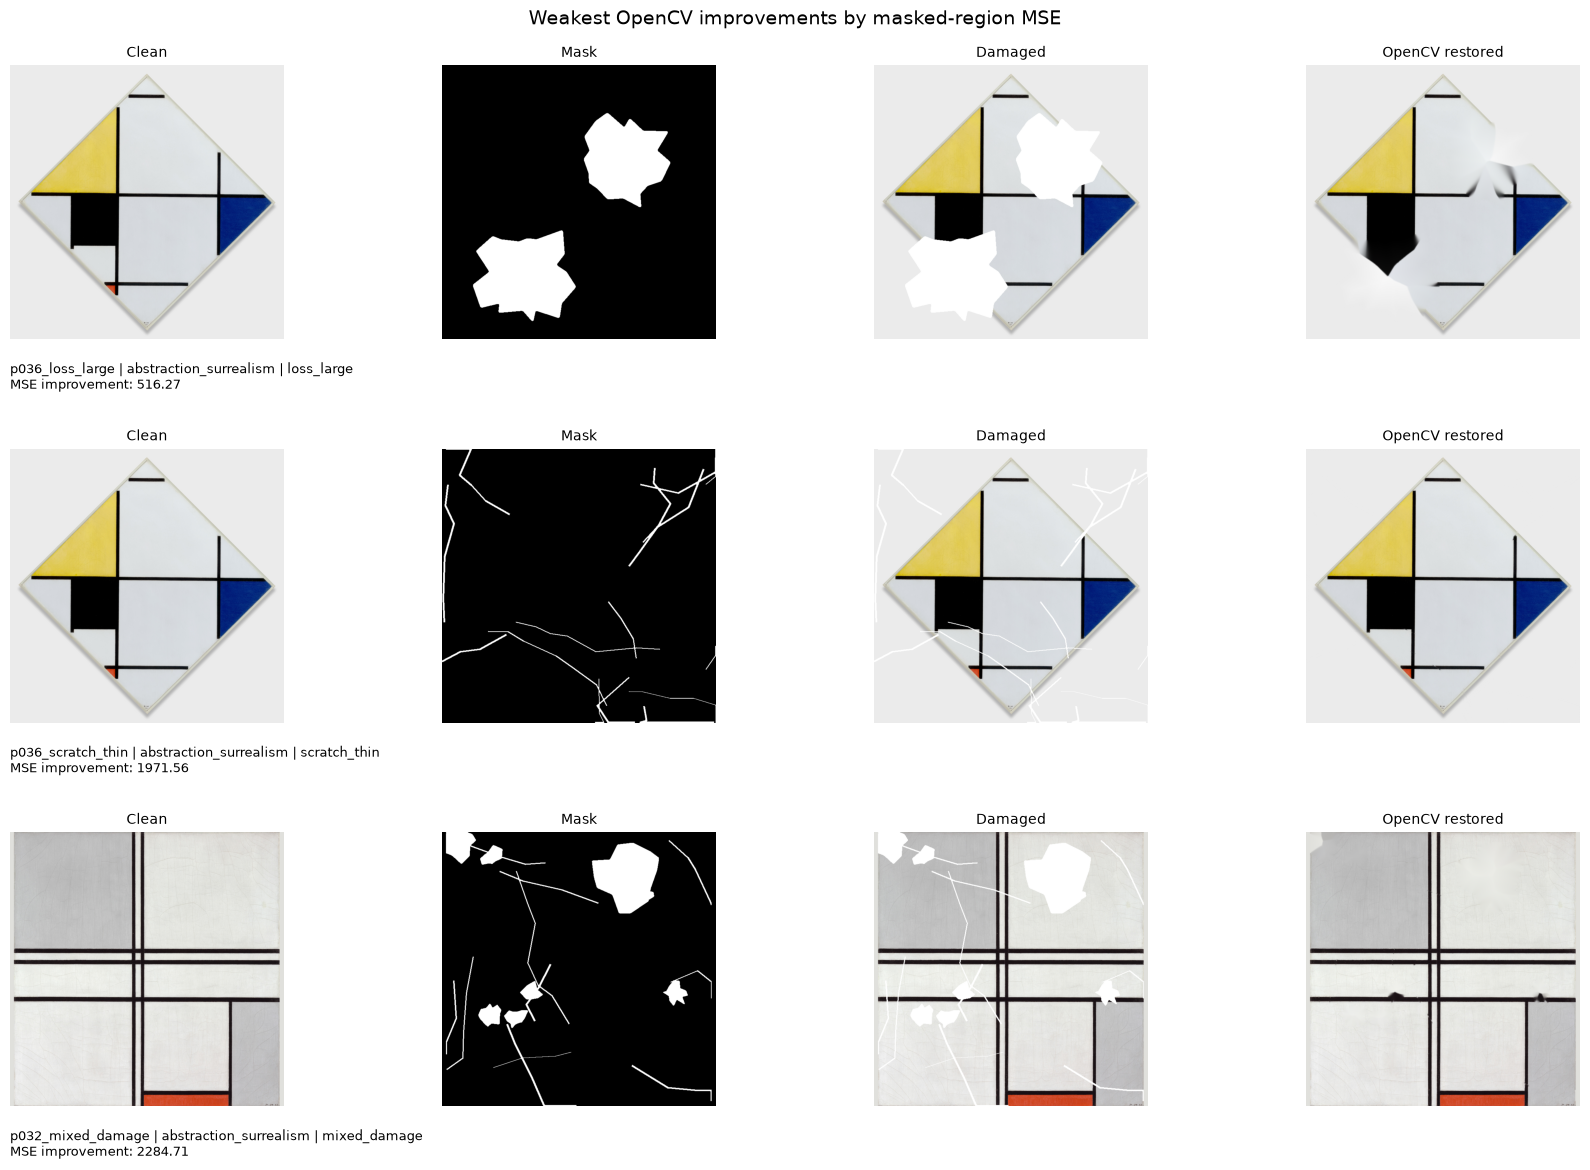

In [19]:
# Visualize weakest OpenCV cases by masked-region MSE improvement

show_case_comparisons(
    weakest_cases_df,
    title="Weakest OpenCV improvements by masked-region MSE",
    max_cases=3,
)

## Interpretation of strongest and weakest OpenCV cases

The strongest and weakest case tables are ranked by absolute masked-region MSE improvement:

`damaged_mse - restored_mse`

This ranking should not be interpreted as a direct ranking of visual restoration quality.

Cases with large absolute improvement often correspond to situations where the white-filled damaged input was extremely different from the clean reference image. In these cases, OpenCV may strongly reduce pixel error by replacing the white damaged region with locally interpolated colors, even when the result appears blurry or lacks fine semantic detail.

This was visible in several portrait examples, where OpenCV reduced the obvious white damage but did not faithfully reconstruct facial, clothing, or brushwork details.

Conversely, cases with smaller absolute improvement may still appear visually close to the original, especially in abstract or geometric paintings. In these images, simpler color regions and lower semantic specificity can make local interpolation appear visually acceptable, even when the absolute MSE improvement is smaller.

Therefore, the strongest/weakest MSE-improvement examples are used as diagnostic cases, not as final qualitative rankings. This supports the broader evaluation-framework argument that pixel-level improvement, perceptual plausibility, semantic correctness, and art-historical faithfulness are related but not equivalent.

## Classical metric evaluation result

Classical full-reference metrics were computed for the OpenCV Telea baseline on the 50-painting controlled subset.

The evaluation compared:

- clean image vs damaged image,
- clean image vs OpenCV-restored image.

Metrics computed:

- MSE
- MAE
- PSNR
- SSIM

Evaluation regions:

- full image,
- painting content region,
- masked region,
- mask bounding-box crop.

SSIM was not computed directly on sparse masked pixels because SSIM requires spatial image structure. For local structural comparison, mask bounding-box crops were used instead.

Summary:

- 900 metric rows were generated,
- zero-control cases produced perfect scores,
- masked-region SSIM values were intentionally left empty,
- all non-zero mask cases showed positive masked-region MSE improvement after OpenCV restoration,
- summary tables were saved by region, mask type, category, and region-mask type,
- strongest and weakest OpenCV cases were exported for later qualitative analysis.

The results show that OpenCV Telea improves pixel-level error compared with the white-filled damaged inputs. This does not imply historically or semantically correct restoration. It only shows that the classical baseline produces outputs numerically closer to the clean images than the synthetic white damage. Later perceptual, feature-based, and qualitative analysis are needed to interpret restoration quality more carefully.